In [1]:
%cd ../.
import os, sys
sys.path.insert(0, os.path.abspath('../Scripts'))
sys.path.insert(0, os.path.expanduser('~/CDD_Vault_API/python'))  # CDD Vault API (get_df)

/home/gtamo/ADME_ML


In [2]:
%load_ext autoreload
%autoreload 2

import re
import os
import pandas as pd
import numpy as np
# import py3Dmol
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import csv
import pickle

from pathlib import Path
from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem,rdFMCS
# import prolif as plf
from glob import glob
# import meeko
import subprocess as sub
# from vina import Vina
import time
from tqdm import tqdm
tqdm.pandas()
import importlib
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, HistGradientBoostingClassifier
from sklearn.dummy import DummyClassifier
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import StratifiedKFold, cross_val_predict, KFold
from sklearn import metrics as _m
from sklearn.metrics import f1_score, silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.metrics import roc_auc_score, average_precision_score, matthews_corrcoef
# from xgboost import XGBClassifier,XGBRegressor
from openTSNE import TSNE as oTSNE        # pip install openTSNE
import seaborn as sns
from scipy import stats
import csv, contextlib, threading, joblib
import joblib
from joblib import Parallel, delayed
from datetime import date
## load internal (in-house) + public-augmented data, champion model, eval helpers
from copy import deepcopy
from itertools import combinations


# user defined modules
import Rdkit_tools as rdkit_tools
importlib.reload(rdkit_tools)
import Molecule as M
import ML_Reg as ML_Reg
import ML_Class as ML_Class
# from MolViz3D import MolViz3D
import Statistics_tools as stats_tools
import python.functions as fn
from python.harmonize_sol import harmonize_solubility

from get_library import get_df   # CDD Vault collection export
from get_protocol_data import get_data, load_config, alias_map
# from tdc.multi_pred import DTI

import yaml
from python.ADME_build_ML import PARAMS, DATA, OUTPUT   # CLI classes reused here (%autoreload picks up edits)
from IPython.display import HTML, display



# FUNCTIONS

In [3]:
# per-endpoint classification sign (favorable/positive class) + modelling-space transform used on the raw cutoff
_EP_SIGN = {'solubility': '>=', 'logd': '<', 'hlm': '<', 'mlm': '<', 'rlm': '<', 'caco2': '>=', 'mdck': '>=', 'ppb': '<'}
_EP_TF   = {'solubility': 'log10', 'logd': 'identity', 'hlm': 'log10', 'mlm': 'log10', 'rlm': 'log10', 'caco2': 'log10', 'mdck': 'log10', 'ppb': 'logit_pct'}
# regression columns: table label -> key in each <exp>_metrics dict (from ML_Reg.get_reg_metrics_from_preddf)
_REG_COLS = {'R2_det': 'r2det', 'R2_pears': 'r2', 'RMSE': 'rmse', 'N': 'n_test', 'n_train': 'n_train'}
_CLS_COLS = ['Accuracy', 'PPV', 'NPV', 'F1(+)', 'F1(-)', 'MCC']
_COLS = list(_REG_COLS) + _CLS_COLS
_HIGHER = {'R2_det', 'R2_pears', 'Accuracy', 'PPV', 'NPV', 'F1(+)', 'F1(-)', 'MCC'}; _LOWER = {'RMSE'}   # N / n_train unscored

def _to_model(raw, tf):   # raw-unit cutoff -> modelling space (pred_df is in modelling space)
    if tf == 'log10':     return np.log10(raw)
    if tf == 'logit_pct': return np.log10(raw / (100.0 - raw))
    return raw

def _classif_metrics(pdf, ctf, sign):   # binary triage metrics from a pred_df at the cutoff
    d = pdf.dropna(subset=['real_y', 'pred_y']); yo = d['real_y'].to_numpy(float); yp = d['pred_y'].to_numpy(float)
    rc, pc = (yo < ctf, yp < ctf) if sign == '<' else (yo >= ctf, yp >= ctf)
    return {'Accuracy': _m.accuracy_score(rc, pc), 'PPV': _m.precision_score(rc, pc, zero_division=0),
            'NPV': _m.precision_score(~rc, ~pc, zero_division=0), 'F1(+)': _m.f1_score(rc, pc, zero_division=0),
            'F1(-)': _m.f1_score(rc, pc, pos_label=False, zero_division=0),
            'MCC': _m.matthews_corrcoef(rc, pc) if (rc.min() != rc.max() and pc.min() != pc.max()) else np.nan}

def endpoint_metrics_table_from_dict(metrics_dict, endpoint):
    """HTML table for one endpoint: <exp>_metrics (regression) + <exp>_preddf (classification @ CUTOFFS[endpoint]).

    One row per experiment (the *_preddf entries are used, not shown as rows). CV rows first, temporal rows
    (key contains 'temp') after a double rule. Best per column = bold cyan, worst = orange, WITHIN each
    category. Returns the numeric DataFrame.
    """
    # cutoff in modelling space + favorable-class sign for this endpoint
    ctf = _to_model(CUTOFFS[endpoint], _EP_TF[endpoint]); sign = _EP_SIGN[endpoint]
    # one row per experiment: regression from <exp>_metrics, classification from <exp>_preddf
    exps = [k[:-len('_metrics')] for k in metrics_dict if k.endswith('_metrics')]
    rows = {}
    for e in exps:
        reg = metrics_dict.get(e + '_metrics', {})
        row = {col: reg.get(src) for col, src in _REG_COLS.items()}
        pdf = metrics_dict.get(e + '_preddf')
        if pdf is not None:
            row.update(_classif_metrics(pdf, ctf, sign))
        rows[e] = row
    df = pd.DataFrame(rows).T.reindex(columns=_COLS).apply(pd.to_numeric, errors='coerce')
    # category: CV (0) vs temporal (1); sort category first, then R2det descending within
    df['_ci'] = [1 if 'temp' in k.lower() else 0 for k in df.index]
    df = df.sort_values(['_ci', 'R2_det'], ascending=[True, False]); ci = df['_ci'].to_numpy()
    # best/worst per scored column, WITHIN each category
    def _bw(sub):
        b, w = {}, {}
        for c in _COLS:
            if c in _HIGHER:  b[c], w[c] = sub[c].max(), sub[c].min()
            elif c in _LOWER: b[c], w[c] = sub[c].min(), sub[c].max()
        return b, w
    bws = {c: _bw(df[df['_ci'] == c]) for c in set(ci)}
    CY, OR = '#0097A7', '#F57C00'
    def _fmt(c, v):
        if c in ('N', 'n_train'): return 'nan' if pd.isna(v) else f'{int(v)}'
        return 'nan' if pd.isna(v) else f'{v:.3g}'
    def _td(c, v, bw, sep=''):
        best, worst = bw; s = _fmt(c, v); base = f'text-align:right;padding:2px 8px{sep}'
        if c in best and not pd.isna(v):
            if v == best[c]:                          return f'<td style="color:{CY};font-weight:700;{base}">{s}</td>'
            if v == worst[c] and worst[c] != best[c]: return f'<td style="color:{OR};{base}">{s}</td>'
        return f'<td style="{base}">{s}</td>'
    # header + body (double rule between CV and temporal)
    th = ''.join(f'<th style="text-align:right;padding:2px 8px;border-bottom:1px solid #999">{c}</th>' for c in _COLS)
    body = ''
    for i, (k, r) in enumerate(df.iterrows()):
        sep = ';border-top:3px double #666' if (i > 0 and ci[i] != ci[i - 1]) else ''
        body += (f'<tr><td style="text-align:left;font-weight:600;padding:2px 8px{sep}">{k}</td>' +
                 ''.join(_td(c, r[c], bws[ci[i]], sep) for c in _COLS) + '</tr>')
    cap = (f'<b>{endpoint}</b> — regression + classification @ cutoff {CUTOFFS[endpoint]:g} (sign {sign}) · '
           f'<span style="color:{CY};font-weight:700">best</span>/<span style="color:{OR}">worst</span> per column, '
           f'within each category (double rule = CV / temporal boundary)')
    display(HTML(f'<div style="font:13px sans-serif"><p>{cap}</p><table style="border-collapse:collapse">'
                 f'<thead><tr><th style="text-align:left;padding:2px 8px;border-bottom:1px solid #999">pred_df</th>{th}</tr></thead>'
                 f'<tbody>{body}</tbody></table></div>'))
    return df[_COLS]


def make_model(use_cuml=False, n_bins=32):
    """Champion RF: sklearn (default) or RAPIDS cuRF on GPU (use_cuml=True; needs the `rapids` kernel, no uq_std/confidence).
    n_bins is the cuRF speed knob (fewer split candidates -> faster; default 32 vs cuML's 128). NOTE: cuRF is slow at
    the full ~4469-feature width regardless of n_bins; reduce features for a real speedup (see README)."""
    if use_cuml:
        from cuml.ensemble import RandomForestRegressor as cuRF
        return cuRF(**cfg['champion'], n_bins=n_bins, n_streams=4, random_state=cfg['seed'])   # cuML has no n_jobs
    return RandomForestRegressor(**cfg['champion'], n_jobs=cfg['n_jobs'], random_state=cfg['seed'])


def transfer(combo, use_cuml=False):
    tr = pub.compound[pub.origin.isin(combo)].tolist()
    _, pr = ML_Reg.K_fold_by_defined_IDs(d, 'compound', [[tr, internal.compound.tolist()]], model=make_model(use_cuml),
                                         col_to_rm=['compound', 'smiles', 'label', 'source', 'origin', '_ik'], v=False)
    y, p = pr.real_y.values, pr.pred_y.values
    return {'combo': '+'.join(o.split(':')[-1] for o in combo), 'n_train': len(tr),
            'R2_pears': np.corrcoef(y, p)[0, 1] ** 2, 'R2_det': 1 - ((y - p) ** 2).sum() / ((y - y.mean()) ** 2).sum(),
            'RMSE': (((y - p) ** 2).mean()) ** 0.5}

def predict_and_record(d, result_df, exp_name='default', ids=None, col_to_rm=None, model=None, use_cuml=False):
    mdl = make_model(True) if use_cuml else (model if model is not None else make_model(False))   # per-run backend choice
    _ , result_df[exp_name + '_preddf'] = ML_Reg.K_fold_by_defined_IDs(d, 'compound', ids, model=mdl, col_to_rm=col_to_rm, v=False, uq=True)
    result_df[exp_name + '_metrics'] = ML_Reg.get_reg_metrics_from_preddf(result_df[exp_name + '_preddf'], ntrain=d.shape[0])

    # assign absolute residual + confidence from the RF tree-variance uncertainty
    result_df[exp_name + '_preddf']['residuals'] = abs(result_df[exp_name + '_preddf']['pred_y'] - result_df[exp_name + '_preddf']['real_y'])
    result_df[exp_name + '_preddf'] = ML_Reg.uq_std_to_confidence(result_df[exp_name + '_preddf'])

    return result_df

# MAIN

In [4]:
## params — every YAML key becomes an attribute (params.ADME_ENDPOINTS); see python/ADME_build_ML.py:PARAMS
CONFIG = 'config/config.yaml'
params = PARAMS(CONFIG)
params.load_params()
## transition shim — keep the bare YAML names (ADME_ENDPOINTS, CUTOFFS, SERAC_C, RF_SINGLETASK, ...) working below
globals().update({k: v for k, v in params.__dict__.items() if k.isupper()})
config = params

> loaded 40 params from config/config.yaml


In [5]:
CUTOFFS = {  # raw units; sign in comment. Conventions, not hard rules — see caveats
  'solubility': 10,    # µM,        >= soluble
  'logd':       3,     # logD7.4,   <= within sweet-spot upper bound (>3 = too lipophilic)
  'caco2':      10,    # 1e-6 cm/s, >= high permeability (fa~0.8-0.9)
  'mdck':       10,    # 1e-6 cm/s, >= high permeability
  'ppb':        1,     # % unbound, <= 1  => highly bound (fu<=0.01)
  'hlm':        12,    # µL/min/mg, < 12  => low clearance/stable  (WEAK: measurement floor, no verified triage cutoff)
  'mlm':        12,    # µL/min/mg, same caveat (mouse)
  'rlm':        12,    # µL/min/mg, same caveat (rat)
}

## model params
cfg = yaml.safe_load(open('config/config.yaml'))['RF_SINGLETASK']
# champion RF (sklearn); per-run cuRF is opt-in via use_cuml=True on transfer() / predict_and_record()
model = RandomForestRegressor(**cfg['champion'], n_jobs=cfg['n_jobs'], random_state=cfg['seed'])

## 0. Imports and data formatting

In [6]:
metrics_results = {} # to hold of the predictive results
output          = OUTPUT(params) # model machinery + result store (see OUTPUT)

## data — internal experimental CDD pull (see python/ADME_build_ML.py:DATA); overwrite=True re-pulls from CDD Vault + re-caches
data = DATA()
data.load_df_internal_exp_all(params) # load internal data from cdd
data.load_combine_dfs(params) # combines internal data with public into 1 big dataset
data.build_MF_features(params, type='H237', date='20260824') # H237 fingerprints for all df_all compounds -> output/features/<date>_MF_features.parquet

> df_internal_exp_all: 326 compounds x 102 columns
> solubility augmented: 17998 rows (internal=121, EXP=17877)
> logd augmented: 4518 rows (internal=318, EXP=4200)
> hlm augmented: 278152 rows (internal=325, EXP=277827)
> mlm augmented: 273963 rows (internal=325, EXP=273638)
> rlm augmented: 276731 rows (internal=39, EXP=276692)
> caco2 augmented: 337779 rows (internal=95, EXP=337684)


/home/gtamo/miniconda3/envs/chemprop/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


> mdck augmented: 336883 rows (internal=109, EXP=336774)
> ppb augmented: 338651 rows (internal=69, EXP=338582)
> df_all: 369138 compounds x 12 cols (8 endpoints; 369138 with >=1 label)
> MF features (H237) [all]: 369138 compounds x 4469 features -> output/features/20260824_MF_features.parquet


## 1. Compute RF performance metrics for all endpoints

In [14]:
endpoints = ['solubility','logd','hlm','mlm','rlm','caco2','mdck','ppb']
for k in endpoints:
    exec('data.build_ML_data_'+k+'()')
    assert stats_tools.check_ML_data(data.ML_data[k], extra_meta_cols=('source', 'origin'),verbose=False)
    data.get_internal_public_sets(k, min_n=1000)
    data.select_best_combo_and_update(params, k)   # combo = BEST_PUBLIC[k] origins present in data.origins

    METRICS_PKL = 'output/results/20260825_metrics/'+k+'.pkl'
    output.assess_predictions(data, METRICS_PKL)   # compute-or-load the 6 arms -> output.metrics_results[k]

> ML_data['solubility']: 17997 rows x 4474 cols (cap 15000 raw)


InChIKey: 100%|██████████| 9/9 [00:00<00:00, 12.52it/s]


> solubility: internal=120, public=17877 (origins > 1000: ['thermodynamic:PharmaBench', 'thermodynamic:ChEMBL', 'thermodynamic:Biogen-Fang', 'thermodynamic:AQUA'])
> loaded metrics_results['solubility'] <- output/results/20260825_metrics/solubility.pkl
> ML_data['logd']: 4516 rows x 4474 cols


InChIKey: 100%|██████████| 3/3 [00:00<00:00,  4.06it/s]


> logd: internal=317, public=4199 (origins > 1000: ['TDC:Lipophilicity_AstraZeneca'])
> loaded metrics_results['logd'] <- output/results/20260825_metrics/logd.pkl
> ML_data['hlm']: 277940 rows x 4474 cols


...

> caco2: internal=95, public=331586 (origins > 1000: ['Novartis-NIBR', 'ADMETlab-PROTAC'])
> loaded metrics_results['caco2'] <- output/results/20260825_metrics/caco2.pkl
> ML_data['mdck']: 330875 rows x 4474 cols


InChIKey:   0%|          | 0/166 [00:00<?, ?it/s][08:44:14] WARNING: not removing hydrogen atom without neighbors
[08:44:15] WARNING: not removing hydrogen atom without neighbors
InChIKey: 100%|██████████| 166/166 [00:04<00:00, 35.50it/s]


> mdck: internal=107, public=330768 (origins > 1000: ['Novartis-NIBR', 'ADMETlab-PROTAC'])
> loaded metrics_results['mdck'] <- output/results/20260825_metrics/mdck.pkl
> ML_data['ppb']: 332471 rows x 4474 cols


InChIKey:   0%|          | 0/167 [00:00<?, ?it/s][08:44:53] WARNING: not removing hydrogen atom without neighbors
[08:44:54] WARNING: not removing hydrogen atom without neighbors
InChIKey: 100%|██████████| 167/167 [00:04<00:00, 35.31it/s]


> ppb: internal=69, public=332402 (origins > 1000: ['Novartis-NIBR', 'ADMETlab-PROTAC', 'TDC:PPBR_AZ'])
> loaded metrics_results['ppb'] <- output/results/20260825_metrics/ppb.pkl


In [9]:
# _ = endpoint_metrics_table_from_dict(output.metrics_results[k], k)

## 2. Individual visualization of RF analysis results

In [11]:
k        = ['solubility', 'logd', 'mdck', 'hlm', 'mlm', 'rlm', 'caco2', 'ppb'][0]
exec('data.build_ML_data_'+k+'()')
assert stats_tools.check_ML_data(data.ML_data[k], extra_meta_cols=('source', 'origin'),verbose=False)
data.get_internal_public_sets(k, min_n=1000)
data.select_best_combo_and_update(params, k)   # combo = BEST_PUBLIC[k] origins present in data.origins

METRICS_PKL = 'output/results/20260825_metrics/'+k+'.pkl'
# METRICS_PKL = 'output/results/tmp/'+k+'.pkl'
output.assess_predictions(data, METRICS_PKL)   # compute-or-load the 6 arms -> output.metrics_results[k]
_ = endpoint_metrics_table_from_dict(output.metrics_results[k], k)

> ML_data['solubility']: 17997 rows x 4474 cols (cap 15000 raw)


InChIKey: 100%|██████████| 9/9 [00:00<00:00, 12.70it/s]


> solubility: internal=120, public=17877 (origins > 1000: ['thermodynamic:PharmaBench', 'thermodynamic:ChEMBL', 'thermodynamic:Biogen-Fang', 'thermodynamic:AQUA'])
> loaded metrics_results['solubility'] <- output/results/20260825_metrics/solubility.pkl


pred_df,R2_det,R2_pears,RMSE,N,n_train,Accuracy,PPV,NPV,F1(+),F1(-),MCC
augmented_cv,0.731,0.738,0.615,120,17997,0.85,0.708,0.944,0.791,0.883,0.687
internal_cv,0.678,0.68,0.672,120,120,0.85,0.738,0.91,0.775,0.887,0.665
ext_->_internal,0.419,0.574,0.903,120,17997,0.583,0.425,0.9,0.576,0.59,0.329
augmented_temp,-1.01,0.076,0.594,36,17997,0.778,0.167,0.9,0.2,0.871,0.0791
internal_temp,-2.44,0.008,0.778,36,17997,0.722,0.125,0.893,0.167,0.833,0.0236
ext_->_temp,-2.82,0.002,0.819,36,17997,0.639,0.2,0.952,0.316,0.755,0.239


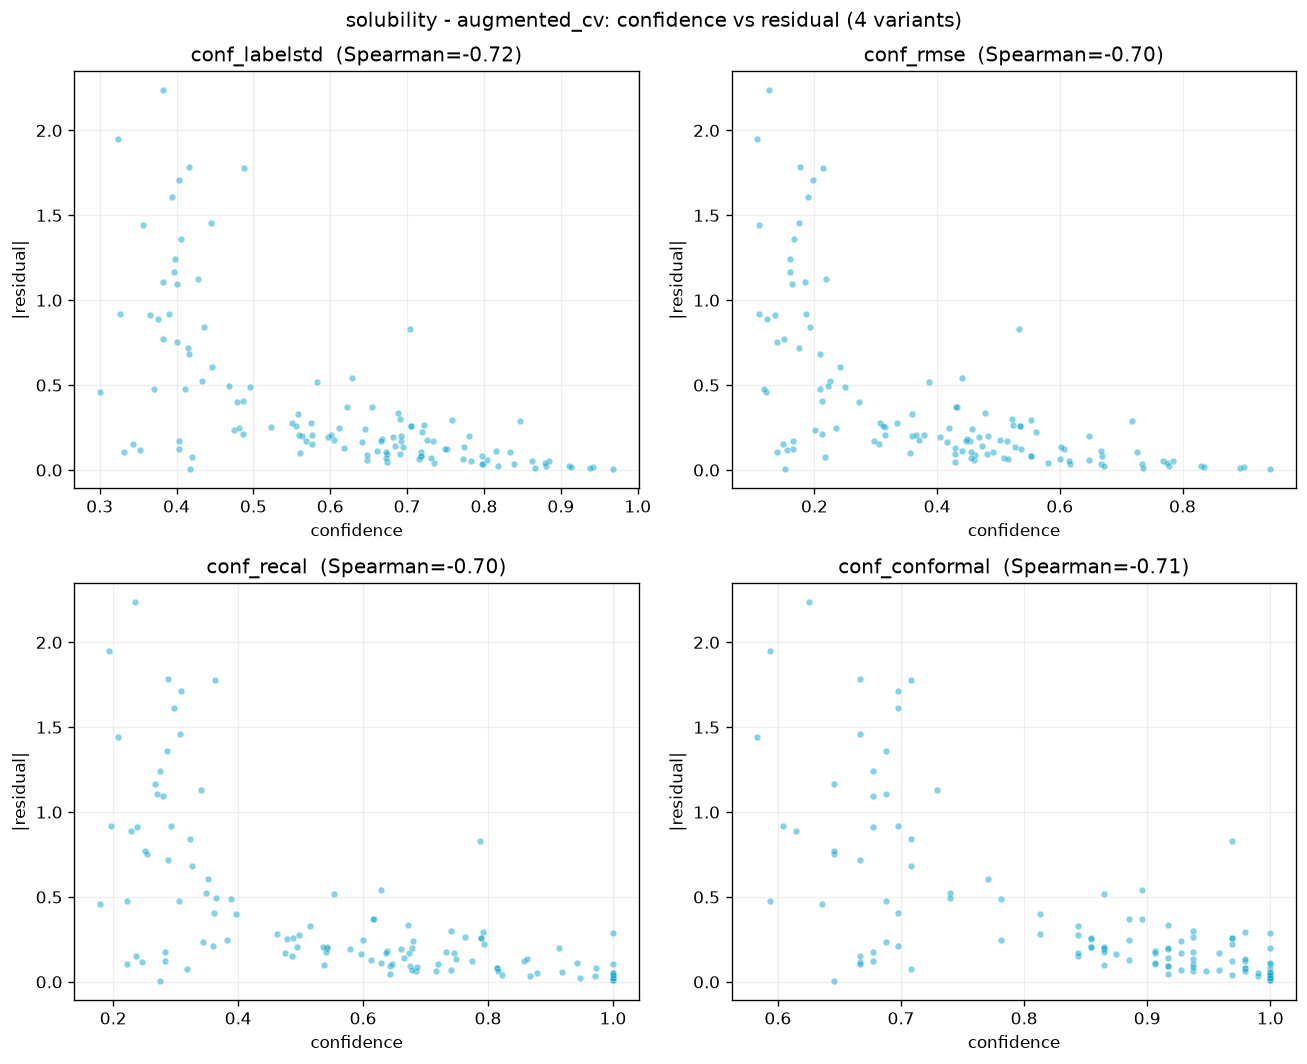

In [12]:
## compare the 4 confidence variants: each conf_* vs |residual| (good = high confidence -> low error)
to_plot   = 'augmented_cv' # 'internal_cv' # 'augmented_temp' #   
pdf       = output.metrics_results[k][to_plot+'_preddf']
conf_cols = ['conf_labelstd', 'conf_rmse', 'conf_recal', 'conf_conformal']
fig, axes = plt.subplots(2, 2, figsize=(11, 9), dpi=120)
for ax, cc in zip(axes.ravel(), conf_cols):
    rho = pdf[cc].corr(pdf['residuals'], method='spearman')   # negative -> higher confidence tracks lower error
    sns.scatterplot(x=cc, y='residuals', data=pdf, color=SERAC_C['azure'], s=16, alpha=0.5, ax=ax)
    ax.set_title(f'{cc}  (Spearman={rho:.2f})'); ax.set_xlabel('confidence'); ax.set_ylabel('|residual|')
    ax.grid(alpha=0.2); ax.set_axisbelow(True)   # grey grid behind points, like plot_parity_from_pred_df
fig.suptitle(f'{k} - {to_plot}: confidence vs residual (4 variants)')
plt.tight_layout(); plt.show()

> parity: n=69
  value: R²pears=0.548 R²det=0.537 RMSE=0.321
> parity: n=15
  value: R²pears=0.416 R²det=0.377 RMSE=0.344


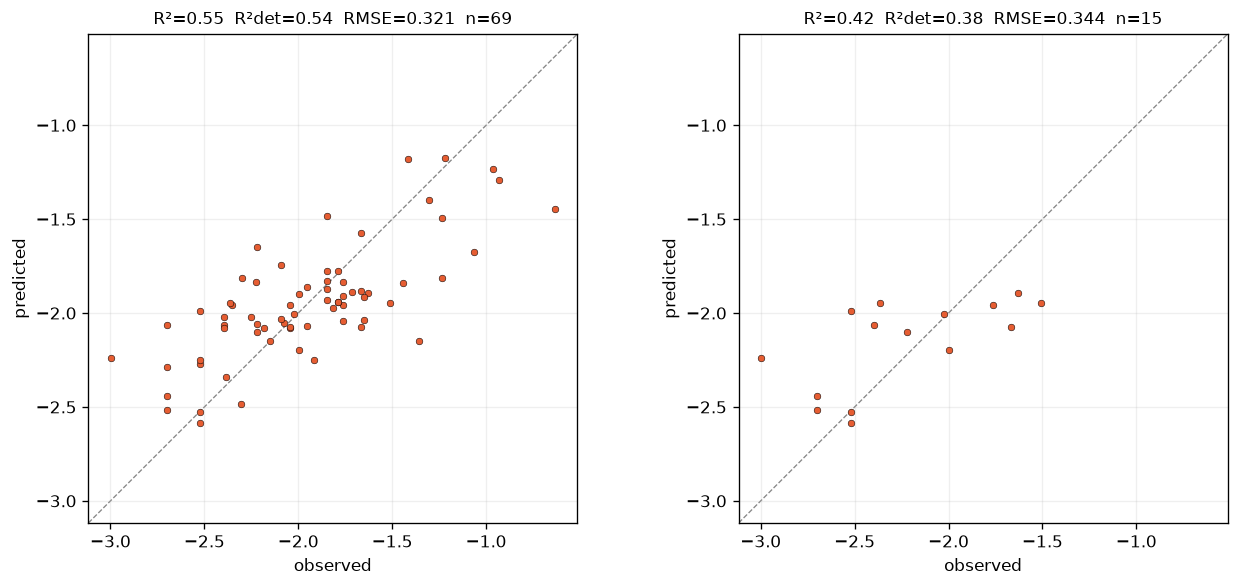

In [51]:
sel_conf   = 'conf_recal' # 'conf_rmse' # 
sel_ctf    = 0.5
sel_preddf = output.metrics_results[k][to_plot+'_preddf'].copy()
sel_preddf = sel_preddf[sel_preddf[sel_conf]>=sel_ctf]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5), dpi=120)
## left: all points; right: confidence-filtered, forced to the SAME x/y limits (lims from the left plot)
res_all = ML_Reg.plot_parity_from_pred_df(output.metrics_results[k][to_plot+'_preddf'], color=SERAC_C['ember'], ax=ax1)
_       = ML_Reg.plot_parity_from_pred_df(sel_preddf, color=SERAC_C['ember'], ax=ax2, lims=res_all['lims'])
plt.tight_layout(); plt.show()

In [ ]:
## run combinatorial analysis ## sol
# output.run_origin_powerset(data)   # scores every public-origin subset via data.transfer
# display(output.res_origin_powerset.round(3))

## 3. Visualize all results

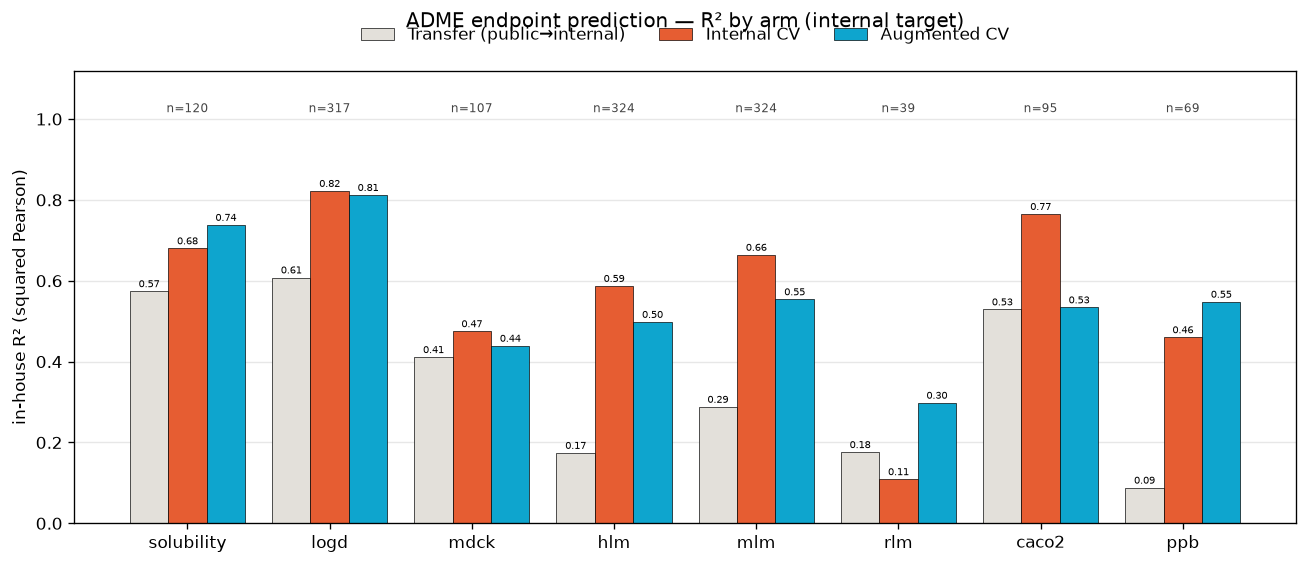

In [15]:
## visualize transfer, internal cv and augmented cv:
ks = ['solubility', 'logd', 'mdck', 'hlm', 'mlm', 'rlm', 'caco2', 'ppb']

## three arms to compare: (arm key in metrics_results, legend label, SERAC color)
arms = [('ext_->_internal', 'Transfer (public→internal)', SERAC_C['paper']),
        ('internal_cv',      'Internal CV',                SERAC_C['ember']),
        ('augmented_cv',     'Augmented CV',               SERAC_C['azure'])]

## squared-Pearson R² per endpoint x arm + the internal test size (same across arms)
r2 = {a: [output.metrics_results[k].get(a + '_metrics', {}).get('r2', np.nan) for k in ks] for a, _, _ in arms}
ns = [output.metrics_results[k].get('internal_cv_metrics', {}).get('n_test', 0) for k in ks]

x = np.arange(len(ks)); w = 0.27
fig, ax = plt.subplots(figsize=(11, 4.8), dpi=120)
## one value-labeled bar group per arm
for i, (a, label, color) in enumerate(arms):
    bars = ax.bar(x + (i - 1) * w, r2[a], w, label=label, color=color, edgecolor='black', linewidth=0.4)
    ax.bar_label(bars, fmt='%.2f', fontsize=6, padding=1)
## internal test size on top of each endpoint
for xi, n in zip(x, ns):
    ax.text(xi, 1.01, f'n={int(n)}', ha='center', va='bottom', fontsize=7, color='#444')
ax.set_xticks(x); ax.set_xticklabels(ks)
ax.set_ylabel('in-house R² (squared Pearson)'); ax.set_ylim(0, 1.12)
ax.set_title('ADME endpoint prediction — R² by arm (internal target)', pad=26)
ax.legend(frameon=False, ncol=3, loc='upper center', bbox_to_anchor=(0.5, 1.13))
ax.grid(axis='y', alpha=0.3); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()


## 4. Chemprop

In [ ]:
## chemprop on train_temp_ids + aug_ids -> test_temp_ids: HPO-best D-MPNN, temporal augmented
# chemprop v2 executable + the HPO-best config (output/chemprop_hpo_best.json: depth 3 / hidden 2400 / ffn 2x300 / dropout 0 / agg sum / bs 64; R²pears 0.671 > RF 0.599 on Biogen-Fang -> internal)
CHEMPROP_BIN = os.path.expanduser('~/miniconda3/envs/chemprop/bin/chemprop')
cp_best = {'depth': 3, 'message_hidden_dim': 2400, 'ffn_num_layers': 2, 'ffn_hidden_dim': 300, 'dropout': 0.0, 'aggregation': 'sum', 'batch_size': 64}
# precomputed H237 descriptastorus (DS_) columns -> reused by chemprop via --descriptors-columns (no native recompute)
ds_cols = [c for c in d_aug.columns if c.startswith('DS_')]
# train D-MPNN on internal-temporal-train + Biogen-Fang public, predict the temporal hold-out
pred_sol_temp_cp = ML_Reg.chemprop_K_fold_by_defined_IDs(
    d_aug, 'compound', [[train_temp_ids + aug_ids, test_temp_ids]], CHEMPROP_BIN, target='label',
    hp=cp_best, task_type='regression', uncertainty='none',
    descriptor_cols=ds_cols, epochs=50, v=True)

# parity in raw µM + both-space metrics + 15 µM triage cross
m_cp = ML_Reg.plot_parity_from_pred_df(pred_sol_temp_cp, transform='log10', abline=15, unit='µM', color=SERAC_C['ember'],
                                       title='chemprop internal+Biogen temporal (HPO-best)')
# gain vs the internal-only RF temporal baseline
print(f"  vs internal-only RF  log10: Δpears {m_cp['orig'][0]-tlog[0]:+.3f} Δdet {m_cp['orig'][1]-tlog[1]:+.3f}")

# triage classification at the 15 µM solubility cutoff
print("\nclassification from regression @ 15 µM (soluble = >= 15):")
ML_Class.classification_from_regression_pred(pred_sol_temp_cp, np.log10(15), sign='>=')

In [ ]:
## chemprop on internal train + aug_ids: temporal augmented D-MPNN (fast hand-picked HP, evidential-epistemic uncertainty)
# chemprop v2 executable + the FAST hand-picked config (wiki 2026-07-22: depth 3 / hidden 300 / ffn 2x300 / dropout 0.146 / agg sum; deployed depth-6 is the heavy one)
CHEMPROP_BIN = os.path.expanduser('~/miniconda3/envs/chemprop/bin/chemprop')
cp_hp, cp_epochs = params.TEMPORAL_FRACTIONS['chemprop_hp'], params.TEMPORAL_FRACTIONS['chemprop_epochs']
# precomputed H237 descriptastorus (DS_) columns -> reused by chemprop via --descriptors-columns (no native recompute)
ds_cols = [c for c in d_aug.columns if c.startswith('DS_')]
# train D-MPNN on internal-temporal-train + Biogen-Fang public, predict the temporal hold-out
pred_sol_temp_cp = ML_Reg.chemprop_K_fold_by_defined_IDs(
    d_aug, 'compound', [[aug_ids , int_ids]], CHEMPROP_BIN, target='label',
    hp=cp_hp, task_type='regression-evidential', uncertainty='evidential-epistemic',
    descriptor_cols=ds_cols, epochs=cp_epochs, v=False)

# parity in raw µM + both-space metrics + 15 µM triage cross
m_cp = ML_Reg.plot_parity_from_pred_df(pred_sol_temp_cp, transform='log10', abline=15, unit='µM', color=SERAC_C['ember'],
                                       title='chemprop internal+Biogen temporal')
# gain vs the internal-only RF temporal baseline
print(f"  vs internal-only RF  log10: Δpears {m_cp['orig'][0]-tlog[0]:+.3f} Δdet {m_cp['orig'][1]-tlog[1]:+.3f}")

# triage classification at the 15 µM solubility cutoff
print("\nclassification from regression @ 15 µM (soluble = >= 15):")
ML_Class.classification_from_regression_pred(pred_sol_temp_cp, np.log10(15), sign='>=')

In [ ]:
## chemprop MC-dropout UQ — plain-regression D-MPNN (fast HP), 30 dropout passes, same temporal split
# train a plain-regression D-MPNN (dropout kept on at inference), predict the temporal hold-out with MC-dropout
pred_sol_temp_cp_drop = ML_Reg.chemprop_K_fold_by_defined_IDs(
    d_aug, 'compound', [[train_temp_ids + aug_ids, test_temp_ids]], CHEMPROP_BIN, target='label',
    hp=cp_hp, task_type='regression', uncertainty='dropout', dropout_sampling_size=30,
    descriptor_cols=ds_cols, epochs=cp_epochs, v=False)
# UQ vs residual — positive Spearman = uncertainty tracks error (useful for triage)
u = pred_sol_temp_cp_drop['uncertainty'].to_numpy(); r = (pred_sol_temp_cp_drop.real_y - pred_sol_temp_cp_drop.pred_y).abs().to_numpy()
rs = stats.spearmanr(u, r)
fig, ax = plt.subplots(figsize=(6.5, 5), dpi=120)
ax.scatter(u, r, s=22, c=SERAC_C['olive'], alpha=0.7, edgecolors='none')
ax.set(xlabel='chemprop MC-dropout uncertainty', ylabel='|residual|  (log10 µM)',
       title=f'temporal test — MC-dropout UQ vs error\nSpearman r={rs.statistic:.2f} (p={rs.pvalue:.2g}), n={len(r)}')
sns.despine(); plt.tight_layout(); plt.show()


In [ ]:
## chemprop ensemble UQ — 5-model ensemble (fast HP), across-member variance, same temporal split
# train a 5-model ensemble, predict the temporal hold-out with ensemble-variance uncertainty
pred_sol_temp_cp_ens = ML_Reg.chemprop_K_fold_by_defined_IDs(
    d_aug, 'compound', [[train_temp_ids + aug_ids, test_temp_ids]], CHEMPROP_BIN, target='label',
    hp=cp_hp, task_type='regression', uncertainty='ensemble', ensemble_size=5,
    descriptor_cols=ds_cols, epochs=cp_epochs, v=False)
# UQ vs residual — positive Spearman = uncertainty tracks error (useful for triage)
u = pred_sol_temp_cp_ens['uncertainty'].to_numpy(); r = (pred_sol_temp_cp_ens.real_y - pred_sol_temp_cp_ens.pred_y).abs().to_numpy()
rs = stats.spearmanr(u, r)
fig, ax = plt.subplots(figsize=(6.5, 5), dpi=120)
ax.scatter(u, r, s=22, c=SERAC_C['gold'], alpha=0.7, edgecolors='none')
ax.set(xlabel='chemprop 5-model ensemble uncertainty', ylabel='|residual|  (log10 µM)',
       title=f'temporal test — ensemble UQ vs error\nSpearman r={rs.statistic:.2f} (p={rs.pvalue:.2g}), n={len(r)}')
sns.despine(); plt.tight_layout(); plt.show()
